# PART7_Simulate_recombination

simulate recombination events based on NAM data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import ast
from numpy import random as rnd
from scipy.stats import gaussian_kde
import random
import copy
import itertools
from tqdm import tqdm
from scipy.stats import zscore

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

# Approximate recombination point

In [2]:
# get recombination points from NAM
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'rb') as p:
    recombination_info = pickle.load(p)

NA_contain_RILs = recombination_info[recombination_info["count"] == -1].id.unique()
recombination_info = recombination_info[~recombination_info.id.isin(NA_contain_RILs)]
recombination_info

,count,same_genotype_regions,recombination_point,chromosome,id,family
0,3,"[[0.0, 27130326], [2.0, 4440886], [0.0, 101417...","[27778880, 32233078, 42377009]",chr01,N01_001,N01_KASALATH
1,3,"[[2.0, 4743440], [0.0, 13422814], [2.0, 136974...","[4961340, 18422625, 32153800]",chr01,N01_002,N01_KASALATH
2,2,"[[0, 695658], [2, 25342328], [0, 16705813]]","[927375, 26537878]",chr01,N01_003,N01_KASALATH
3,3,"[[2.0, 4681766], [0.0, 9940825], [2.0, 2589687...","[4880813, 14856482, 40772672]",chr01,N01_004,N01_KASALATH
4,3,"[[2.0, 6675501], [0.0, 16553406], [2.0, 100563...","[6854589, 23663072, 33749866]",chr01,N01_005,N01_KASALATH
...,...,...,...,...,...,...
36523,3,"[[2.0, 6966265], [0.0, 973551], [2.0, 15985206...","[8322037, 9363085, 26190554]",chr12,N22_244,N22_HAYAYUKI
36524,1,"[[0.0, 6303808], [2.0, 19461673]]",[7502115],chr12,N22_245,N22_HAYAYUKI
36525,1,"[[2, 25550694], [0, 624250]]",[26853650],chr12,N22_248,N22_HAYAYUKI
36526,0,"[[0, 26365799]]",[],chr12,N22_249,N22_HAYAYUKI


chr01


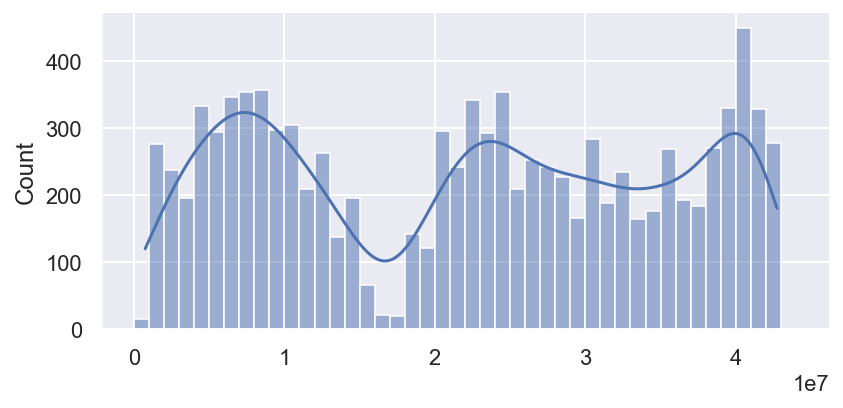

chr02


<Figure size 432x288 with 0 Axes>

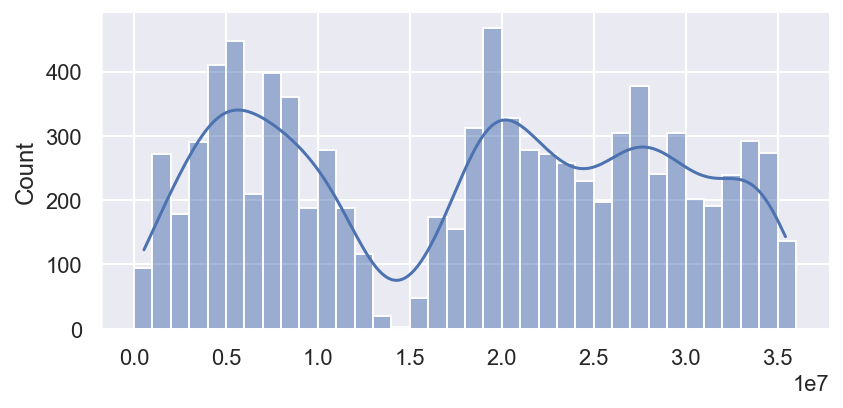

chr03


<Figure size 432x288 with 0 Axes>

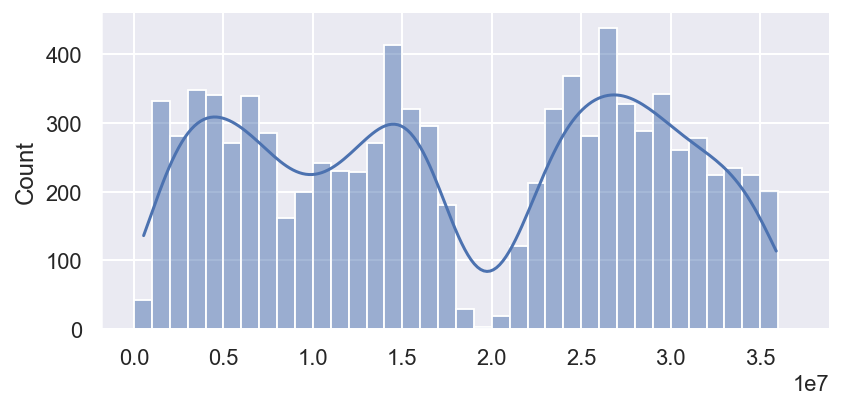

chr04


<Figure size 432x288 with 0 Axes>

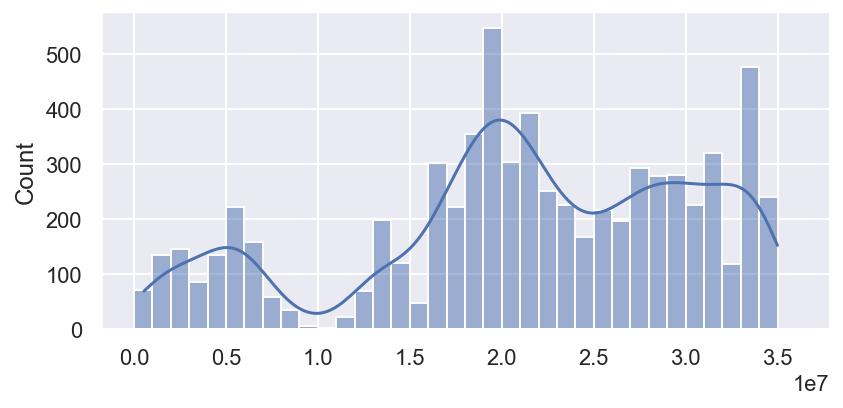

chr05


<Figure size 432x288 with 0 Axes>

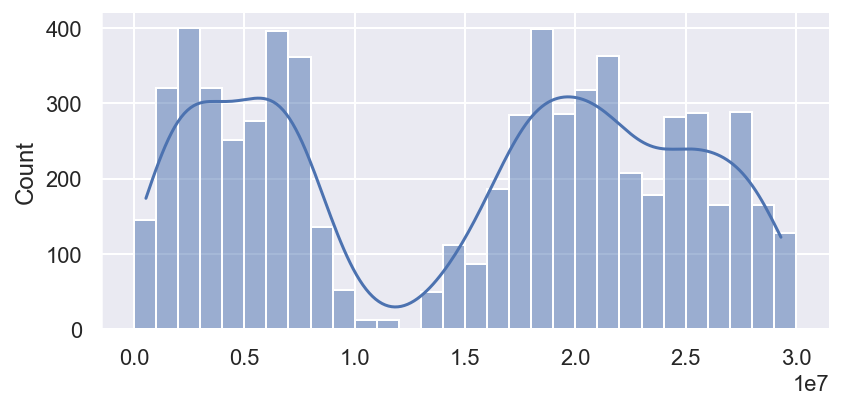

chr06


<Figure size 432x288 with 0 Axes>

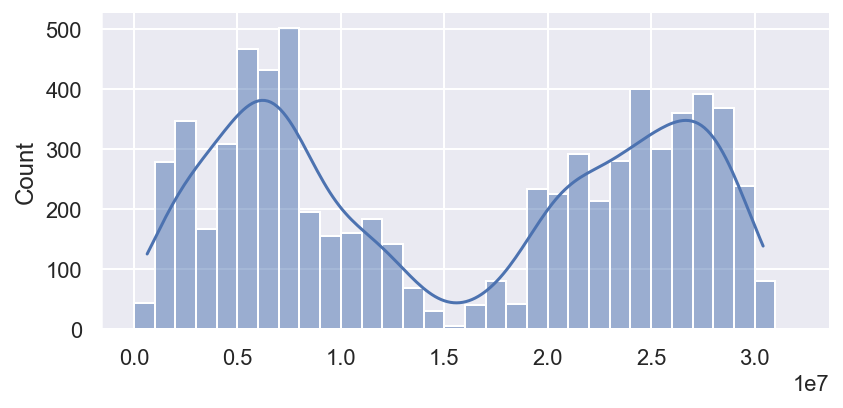

chr07


<Figure size 432x288 with 0 Axes>

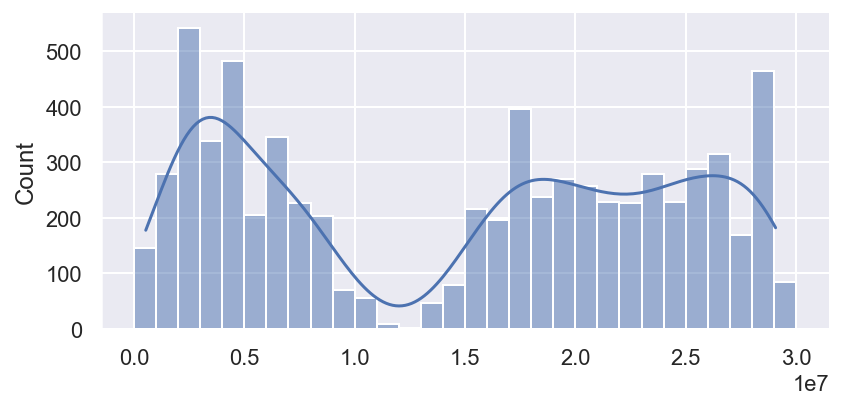

chr08


<Figure size 432x288 with 0 Axes>

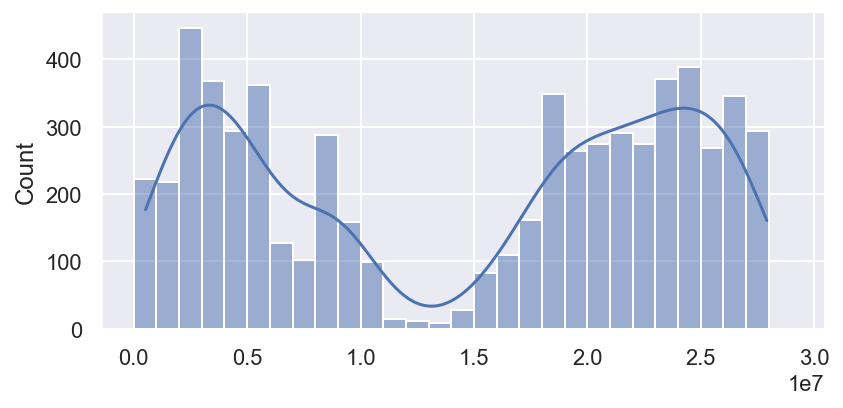

chr09


<Figure size 432x288 with 0 Axes>

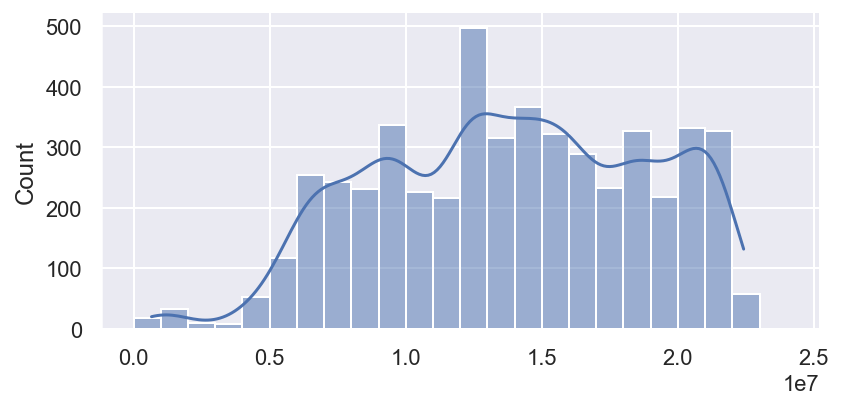

chr10


<Figure size 432x288 with 0 Axes>

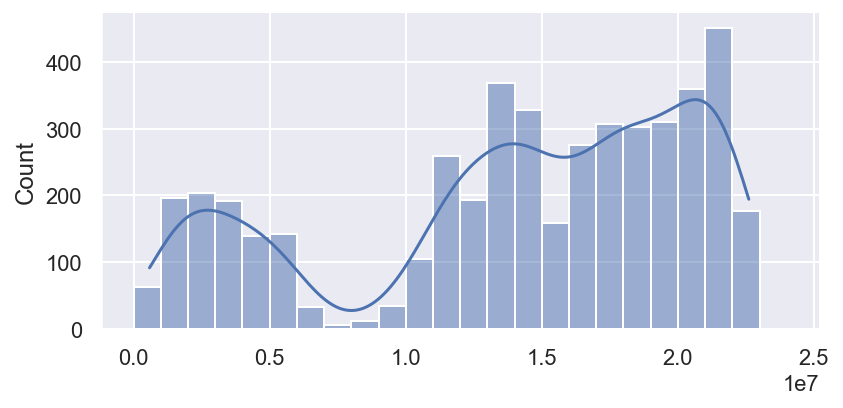

chr11


<Figure size 432x288 with 0 Axes>

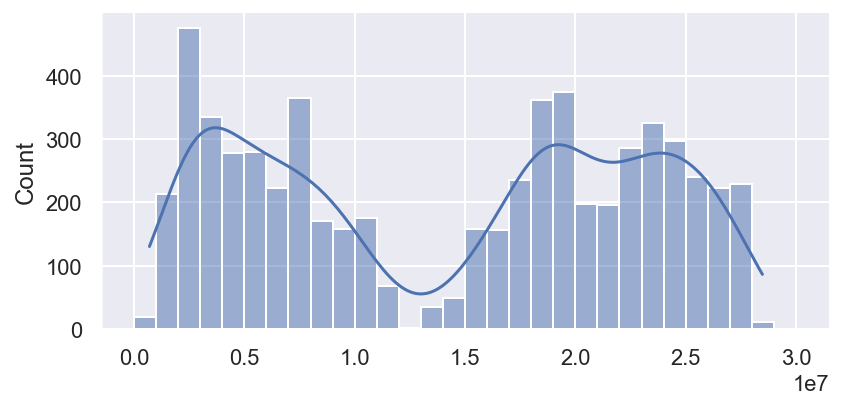

chr12


<Figure size 432x288 with 0 Axes>

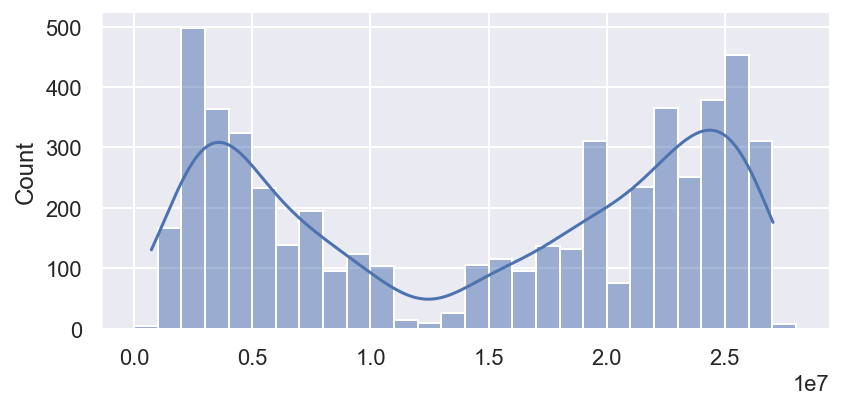

<Figure size 432x288 with 0 Axes>

In [4]:
chr_length = pd.read_csv("../data/chromosome_length.csv")
for each_chr in chr_length.chr.unique():
    print(each_chr)
    each_chr_length = chr_length.loc[chr_length.chr == each_chr, "length"].values[0]
    chr_recombination_info = recombination_info[recombination_info.chromosome == each_chr]
    recombination_points = list(itertools.chain.from_iterable(chr_recombination_info.recombination_point.values))
    bins = [i*1000000 for i in range(each_chr_length // 1000000 + 2)]
    sns.displot(recombination_points, kde=True, bins=bins, height=3, aspect=2)
    plt.show()
    plt.clf()
    
    # sampling
    # kernel = gaussian_kde(recombination_points)
    # kernel.resample(3)[0]

# Approximate number of recombinations

chr01


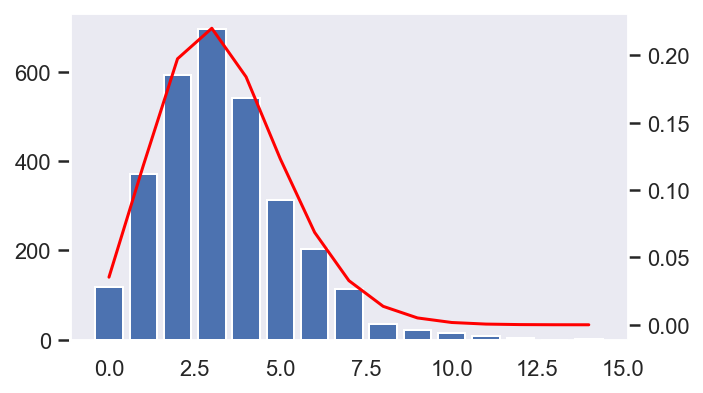

t = 98.79、p = 2.886579864025407e-15 chr02


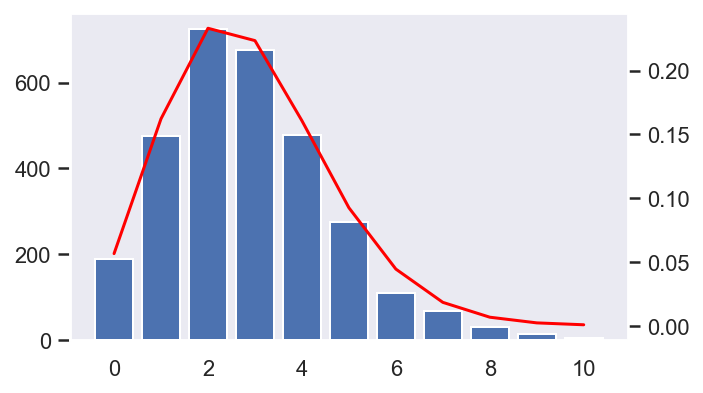

t = 19.92、p = 0.018421813681510524 chr03


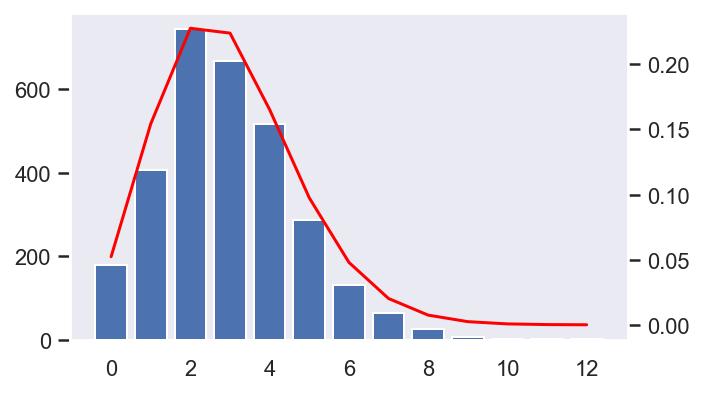

t = 25.04、p = 0.00898686037712959 chr04


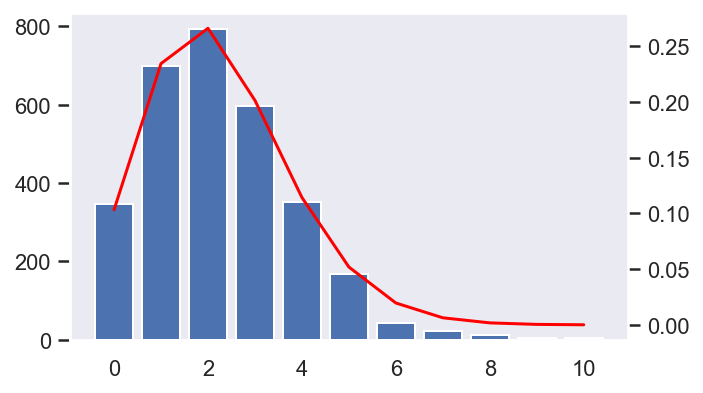

t = 55.19、p = 1.1206561789656178e-08 chr05


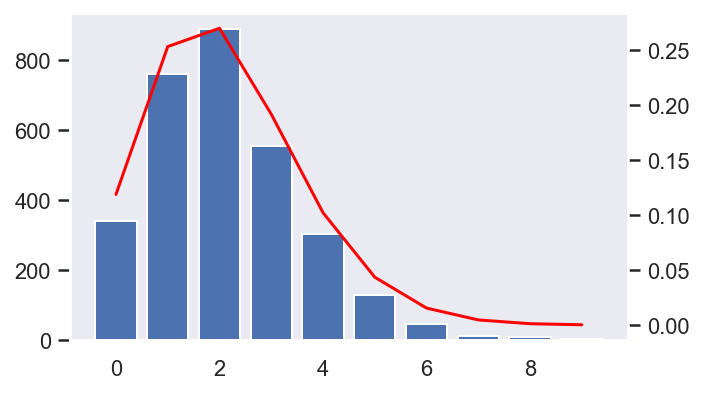

t = 16.68、p = 0.033623751666226775 chr06


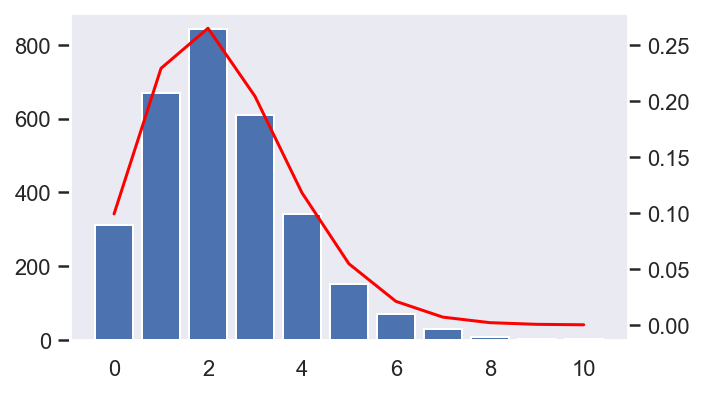

t = 14.24、p = 0.1140168564805567 chr07


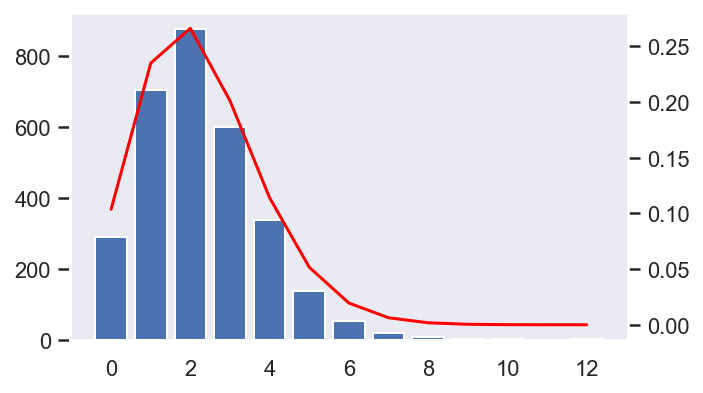

t = 82.78、p = 4.277689313880728e-13 chr08


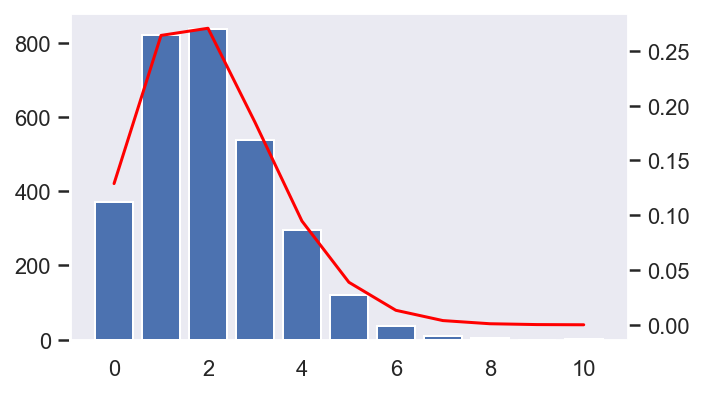

t = 8.10、p = 0.5245790636197909 chr09


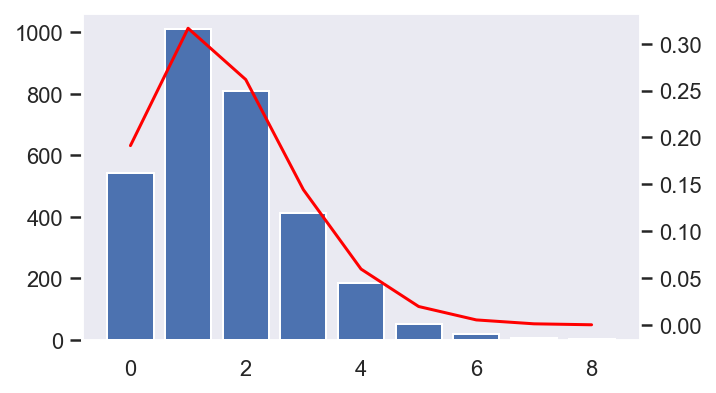

t = 10.55、p = 0.159484671873538 chr10


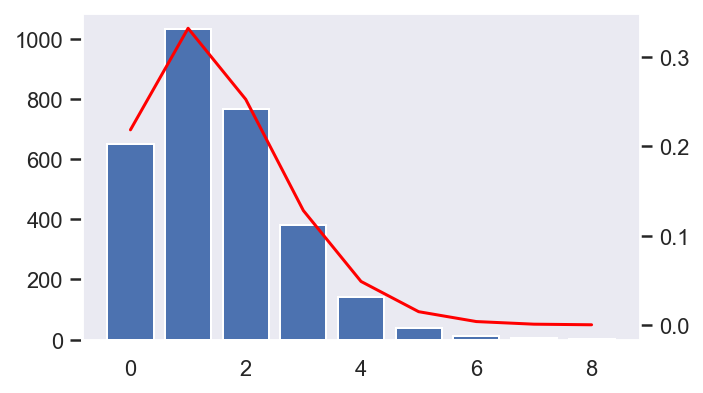

t = 17.57、p = 0.014061161272127198 chr11


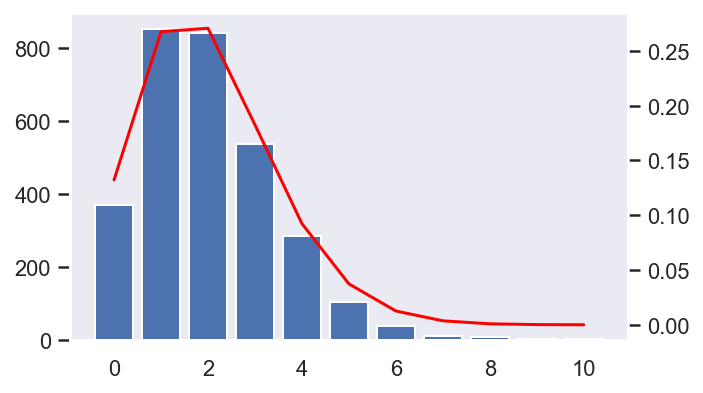

t = 32.73、p = 0.0001485921683264113 chr12


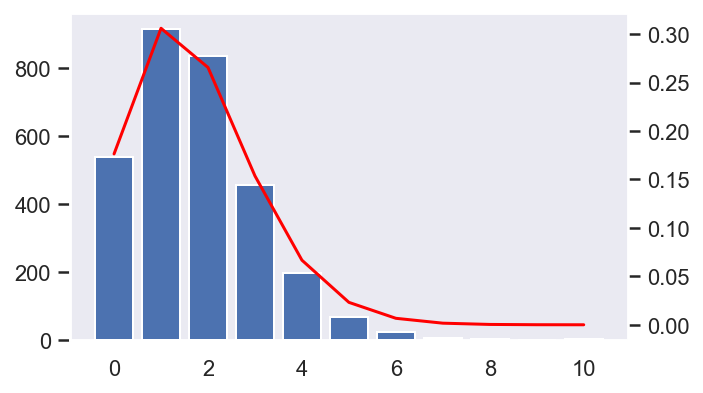

t = 26.36、p = 0.0017812057941835047 

In [8]:
import math
import scipy.stats as st
from scipy.stats import poisson

def poisson(lambda_, k):
    k = int(k)
    result = (lambda_**k) * (math.exp(-lambda_))  / math.factorial(k)
    return result
sns.set()

for each_chr in chr_length.chr.unique():
    print(each_chr)
    chr_recombination_info = recombination_info[recombination_info.chromosome == each_chr]
    frequency = [(chr_recombination_info["count"] == i).sum() for i in range(chr_recombination_info["count"].max()+1)]
    
    fig = plt.figure(figsize=(5,3))

    ax1 = fig.subplots()
    ax2 = ax1.twinx()
    
    ax1.grid(False)
    ax2.grid(False)

    ax1.bar(x=range(chr_recombination_info["count"].max()+1), height=frequency)
    
    k = np.arange(0, chr_recombination_info["count"].max()+1, 1)
    pmf = [poisson(chr_recombination_info["count"].values.mean(), i) for i in k]
    
    ax2.plot(k, pmf, color="red")
    plt.show()
    
    # test distribution
    n = np.arange(0, chr_recombination_info["count"].max()+1)
    f = np.array(frequency)

    mu = chr_recombination_info["count"].values.mean()
    Po = st.poisson(mu=mu)
    xp = Po.pmf(k=n)
    xp[-1] = 1 - st.poisson.cdf(n[-2],mu=mu)
    fp = xp * f.sum()

    t = ( ((f-fp)**2)/fp ).sum()
    p = 1 - st.chi2.cdf(t,df=len(n)-2)

    print(f't = {t:.2f}、p = {p} ',end='')

# Simulate recombination number & points

In [75]:
each_chr = "chr01"
chr_recombination_info = recombination_info[recombination_info.chromosome == each_chr]
recombination_points = list(itertools.chain.from_iterable(chr_recombination_info.recombination_point.values))
# simulate recombination number
recom_num = np.random.poisson(chr_recombination_info["count"].mean(), 1)[0]
# simulate recombination points
kernel = gaussian_kde(recombination_points)
recom_pos = kernel.resample(recom_num)[0]

# check consistency between simulated NAM and real NAM statistics

In [4]:
import random
import copy
import ast
import math
import numpy as np
import pandas as pd
import pickle
import itertools
from scipy.stats import gaussian_kde
from scipy.stats import kstest

from tqdm import tqdm
from modules.simulation import get_recombination_points, convert_genotype_to_pair, cross, check_target_regions, check_approximate_Hitomebore_ratio

In [5]:
# genome size
total_length = sum(pd.read_csv("../data/chromosome_length.csv").length.values)

# get recombination points from NAM
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'rb') as p:
    recombination_info = pickle.load(p)

NA_contain_RILs = recombination_info[recombination_info["count"] == -1].id.unique()
recombination_info = recombination_info[~recombination_info.id.isin(NA_contain_RILs)]

genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
chr_ends = []
for i, each_chr in enumerate(genotype.chr.unique()):
    chr_genotype = genotype[genotype["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
    chr_ends.append(end)
pos_array = genotype.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
genotype["start"] = pos[:, 0]
genotype["end"] = pos[:, 1]

# make genotype of Hitomebore
genotype_Hitomebore = genotype.loc[:, ["chr", "start", "end"]]
genotype_Hitomebore = pd.concat([genotype_Hitomebore,
                                 pd.DataFrame({"Hitomebore_1"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_1_color":np.repeat("H", genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2_color":np.repeat("H", genotype_Hitomebore.shape[0])})],
                                axis=1)
# make genotyoe of Founder
genotype_Founder = genotype.loc[:, ["chr", "start", "end"]]
genotype_Founder = pd.concat([genotype_Hitomebore,
                              pd.DataFrame({"Founder_1"      :np.repeat(1, genotype_Founder.shape[0]),
                                            "Founder_1_color":np.repeat("F", genotype_Founder.shape[0]),
                                            "Founder_2"      :np.repeat(1, genotype_Founder.shape[0]),
                                            "Founder_2_color":np.repeat("F", genotype_Founder.shape[0])})],
                              axis=1)

In [6]:
def get_recombination_points2(recombination_points, average_recom_num):
    np.random.seed(seed=random.randint(0, 10000))
    # simulate recombination number
    recom_num = np.random.poisson(average_recom_num / 2, 1)[0]
    # simulate recombination points
    kernel = gaussian_kde(recombination_points)
    recom_points = kernel.resample(recom_num, seed=random.randint(0, 10000))[0]
    return np.sort(recom_points)

def get_recombination_info(genotype, threshold_length):
    
    recombination_info_chr = []
    for ril in genotype.columns[2:]:    
        x = genotype.loc[:, ["chr", "pos", ril]].dropna()
        current_set = []
        same_genotype_regions = []
        for idx, i in enumerate(x[ril].values):
            if len(current_set) == 0:
                current_set.append(i)
                each_same_genotype_region = [i, idx]
            else:
                if current_set[0] != i:
                    each_same_genotype_region.append(idx)
                    same_genotype_regions.append(each_same_genotype_region)
                    current_set = [i]
                    each_same_genotype_region = [i, idx]
                else:
                    current_set.append(i)
        each_same_genotype_region.append(idx)
        same_genotype_regions.append(each_same_genotype_region)

        new_same_genotype_regions = []
        recombination_point = []
        for i in same_genotype_regions:
            length = x.iloc[i[1]:i[2], :].pos.max() - x.iloc[i[1]:i[2], :].pos.min()
            if length >= threshold_length:
                if len(new_same_genotype_regions) > 0:
                    if new_same_genotype_regions[-1][0] == i[0]:
                        new_same_genotype_regions[-1] = [i[0],  int(new_same_genotype_regions[-1][1] + length)]
                    else:
                        recombination_point.append(x.iloc[i[1], :].pos)
                        new_same_genotype_regions.append([i[0], length])
                else:
                    new_same_genotype_regions.append([i[0], length])
        recombination_info_chr.append([len(new_same_genotype_regions)-1, new_same_genotype_regions, recombination_point])
    recombination_info_chr = pd.DataFrame(recombination_info_chr)
    recombination_info_chr.columns = ["count", "same_genotype_regions", "recombination_point"]

    return recombination_info_chr

def get_input_for_recombination(recombination_info):
    input_data = []
    for i in range(1,13):
        tmp_chr = "chr{}".format(str(i).zfill(2))
        chr_recombination_info = recombination_info[recombination_info.chromosome == tmp_chr]
        recombination_points = list(itertools.chain.from_iterable(chr_recombination_info.recombination_point.values))
        recombination_points.sort()
        average_count = chr_recombination_info["count"].mean()
        input_data.append([recombination_points, average_count])
    input_data = pd.DataFrame(input_data)
    input_data.columns = ["pos", "ave_num"]
    input_data.index = ["chr{}".format(str(i).zfill(2)) for i in range(1, 13)]
    return input_data

def cross2(parent1_genotype, parent2_genotype, parent1, parent2, progeny, input_recom_data):
        
    gametes = parent1_genotype.loc[:, ["chr", "start", "end"]]
    # generate possible gametes for each parent
    for parent in [[parent1, parent1_genotype], [parent2, parent2_genotype]]:
        parent_name = parent[0]
        parent_genotype = parent[1]
        each_parent_gamete = pd.DataFrame()
        # generate possible gamate for each chromosome
        for each_chr in parent_genotype.chr.unique():
            chr_genotype = parent_genotype.loc[parent_genotype.chr == each_chr, :]
            parent_gamete1 = chr_genotype.loc[:, [f"{parent_name}_1", f"{parent_name}_1_color"]]
            parent_gamete1.columns = ["genotype", "color"]
            parent_gamete2 = chr_genotype.loc[:, [f"{parent_name}_2", f"{parent_name}_2_color"]]
            parent_gamete2.columns = ["genotype", "color"]
            # simulate recombination events
            recombination_points = get_recombination_points2(input_recom_data.loc[each_chr, "pos"], input_recom_data.loc[each_chr, "ave_num"])
            recombination_num = len(recombination_points)
            # no recombination -> which gamete
            if recombination_num == 0:
                if random.randint(0, 1) == 0:
                    chr_gamete = parent_gamete1
                else:
                    chr_gamete = parent_gamete2
            else:
                # recombination -> simulate exchange regions
                change_region = np.repeat(False, chr_genotype.shape[0])
                for j in range(recombination_num // 2 + 1):
                    if j == 0:
                        change_region[chr_genotype["start"] < recombination_points[j]] = True
                    elif (j == recombination_num // 2) & (recombination_num % 2 == 0):
                        change_region[chr_genotype["start"] >= recombination_points[j*2-1]] = True
                    else:
                        change_region[(chr_genotype["start"] >= recombination_points[j*2-1]) & (chr_genotype["start"] < recombination_points[j*2])] = True
                # possible gamete genotypes                
                gamete1 = copy.copy(parent_gamete1)
                gamete1.loc[change_region, :] = parent_gamete2.loc[change_region, :]
                gamete2 = copy.copy(parent_gamete2)
                gamete2.loc[change_region, :] = parent_gamete1.loc[change_region, :]
                possible_gametes = [gamete1, gamete2]
                chr_gamete = possible_gametes[random.randint(0, 1)]
            each_parent_gamete = pd.concat([each_parent_gamete, chr_gamete])
        gametes = pd.concat([gametes, each_parent_gamete], axis=1)
    gametes.columns = ["chr", "start", "end", f"{progeny}_1", f"{progeny}_1_color", f"{progeny}_2", f"{progeny}_2_color"]
    return gametes

In [7]:
def F2_breeding(F1_genotype, pop_n, input_recom_data):
    F2_genotypes = []
    for i in range(pop_n):
        F2_genotypes.append(cross2(F1_genotype, F1_genotype, "F1", "F1", "F2", input_recom_data))
    return F2_genotypes

def self_breeding(pop_genotypes, pop_generation, next_generation, input_recom_data):
    next_gen_genotypes = []
    for i in range(len(pop_genotypes)):
        next_gen_genotypes.append(cross2(pop_genotypes[i], pop_genotypes[i], pop_generation, pop_generation, next_generation, input_recom_data))
    return next_gen_genotypes

def make_F6_genotypes(genotype_Hitomebore, genotype_Founder, pop_n, recombination_info, seed):
    random.seed(seed)
    input_recom_data = get_input_for_recombination(recombination_info)
    # F1
    F1_genotype = cross2(genotype_Hitomebore, genotype_Founder, "Hitomebore", "Founder", "F1", input_recom_data)
    # F2
    F2_genotypes = F2_breeding(F1_genotype, pop_n, input_recom_data)
    # F3
    F3_genotypes = self_breeding(F2_genotypes, "F2", "F3", input_recom_data)
    # F4
    F4_genotypes = self_breeding(F3_genotypes, "F3", "F4", input_recom_data)
    # F5
    F5_genotypes = self_breeding(F4_genotypes, "F4", "F5", input_recom_data)
    # F6
    return self_breeding(F5_genotypes, "F5", "F6", input_recom_data)

In [8]:
# simulate F6 population
NAM_population = make_F6_genotypes(genotype_Hitomebore, genotype_Founder, 250, recombination_info, 1024)

In [9]:
tmp = NAM_population[0].loc[:, ["chr", "start"]]
tmp.columns = ["chr", "pos"]
tmp = tmp.reset_index(drop=True)
tmp = pd.concat([tmp, pd.DataFrame([i.loc[:, ["F6_1", "F6_2"]].sum(axis=1).values for i in NAM_population]).T], axis=1)

In [10]:
recombination_info2 = pd.DataFrame()
for tmp_chr in tmp.chr.unique():
    genotype = tmp.loc[tmp.chr == tmp_chr, :]
    recombination_info_chr = get_recombination_info(genotype, 500000)
    recombination_info_chr["chromosome"] = tmp_chr
    recombination_info2 = pd.concat([recombination_info2, recombination_info_chr], axis=0)

recombination_info2

,count,same_genotype_regions,recombination_point,chromosome
0,5,"[[0, 7139734], [2, 5786256], [1, 1847913], [0,...","[7358084, 13222491, 15116698, 15862630, 17047432]",chr01
1,2,"[[2, 10032688], [0, 12786274], [2, 20209169]]","[10238930, 23029640]",chr01
2,2,"[[2, 13936046], [0, 672284], [2, 28394754]]","[14146375, 14844055]",chr01
3,2,"[[2, 27607204], [1, 510008], [0, 14859539]]","[27850807, 28379270]",chr01
4,3,"[[0, 3953095], [2, 23222698], [0, 7132731], [1...","[4150216, 27544195, 34727610]",chr01
...,...,...,...,...
245,2,"[[1, 3063147], [2, 17069728], [0, 7025052]]","[3283967, 20501079]",chr12
246,2,"[[0, 4033892], [2, 12293717], [0, 10539679]]","[4413115, 16986452]",chr12
247,0,"[[2, 26909347]]",[],chr12
248,1,"[[0, 4469901], [2, 22837062]]",[4689069],chr12


chr01


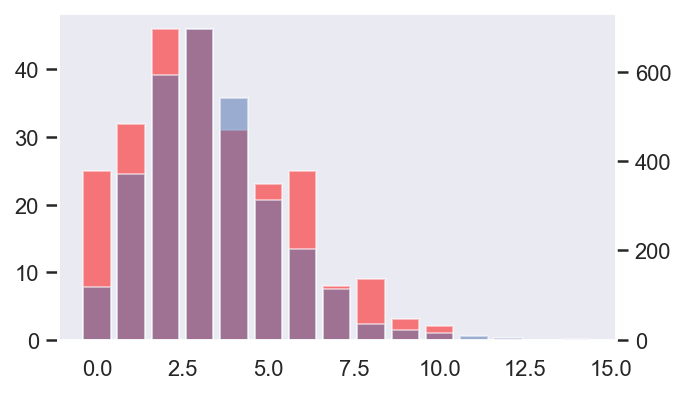

KstestResult(statistic=0.06649703361898483, pvalue=0.24689283234934722, statistic_location=1, statistic_sign=1)
chr02


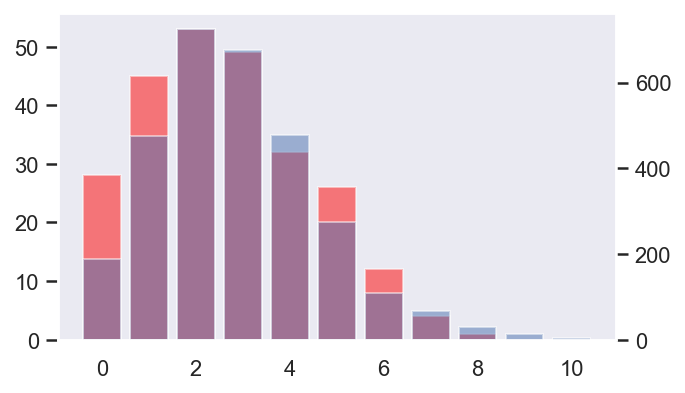

KstestResult(statistic=0.07380619644034278, pvalue=0.1530780699036334, statistic_location=1, statistic_sign=1)
chr03


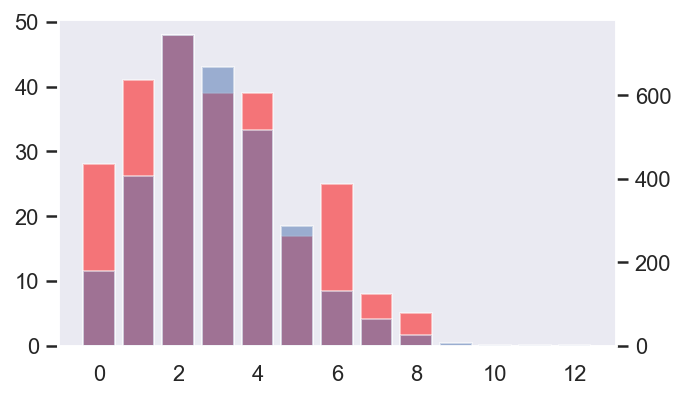

KstestResult(statistic=0.08318523401450231, pvalue=0.07696503217119563, statistic_location=1, statistic_sign=1)
chr04


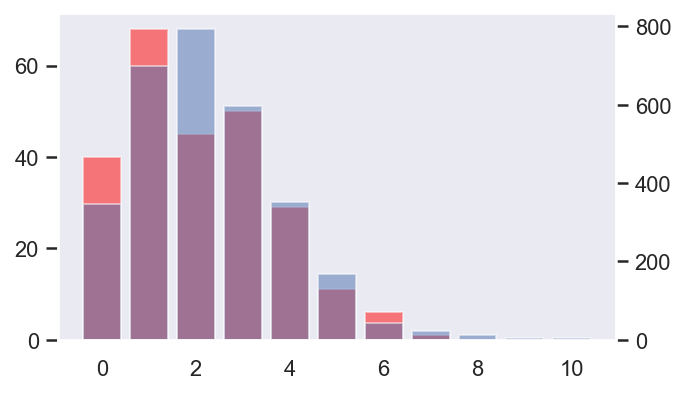

KstestResult(statistic=0.08822940013183915, pvalue=0.05139371719877777, statistic_location=1, statistic_sign=1)
chr05


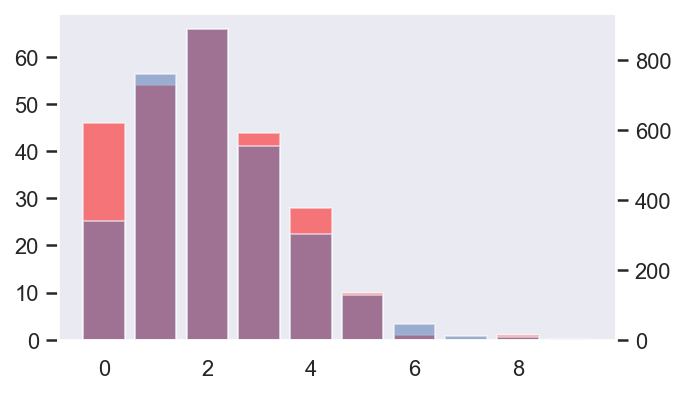

KstestResult(statistic=0.07226631509558339, pvalue=0.17001416411601067, statistic_location=0, statistic_sign=1)
chr06


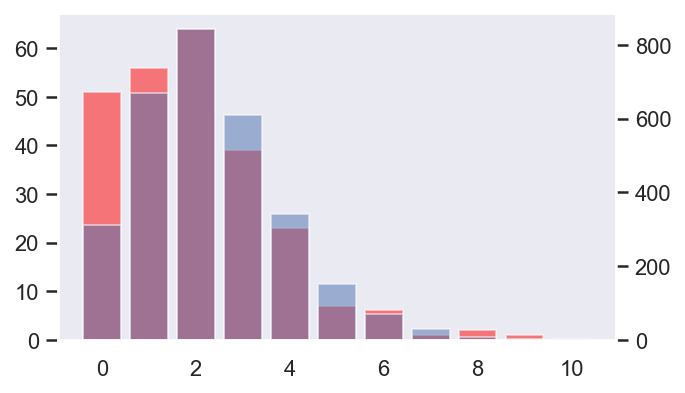

KstestResult(statistic=0.10499406723796968, pvalue=0.011321364536128357, statistic_location=1, statistic_sign=1)
chr07


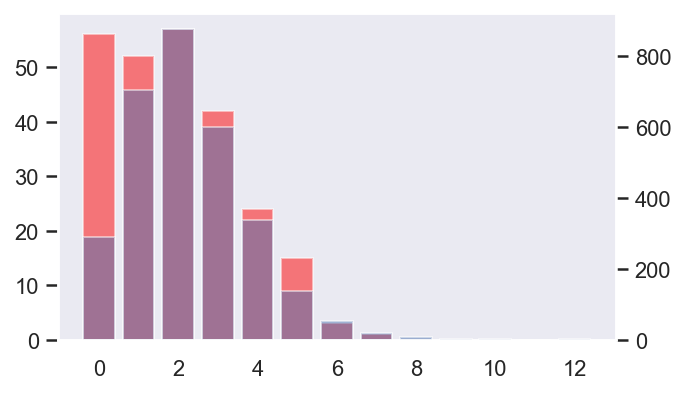

KstestResult(statistic=0.1287462096242584, pvalue=0.000846164093246422, statistic_location=0, statistic_sign=1)
chr08


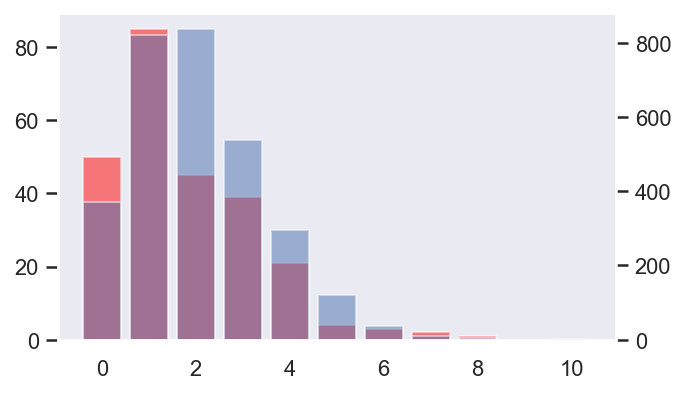

KstestResult(statistic=0.1471193144363876, pvalue=7.900216585805028e-05, statistic_location=1, statistic_sign=1)
chr09


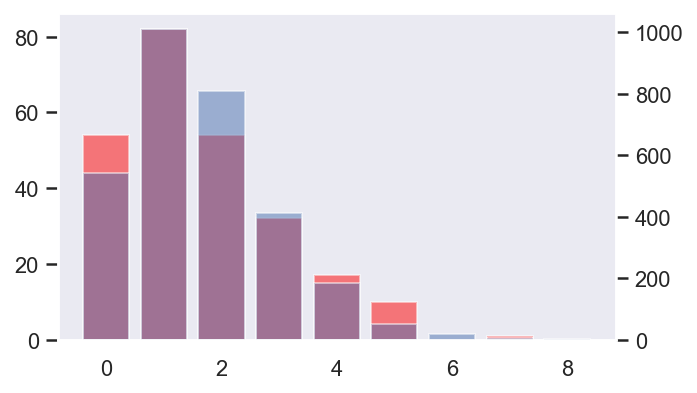

KstestResult(statistic=0.03735794330916282, pvalue=0.8907526258547511, statistic_location=0, statistic_sign=1)
chr10


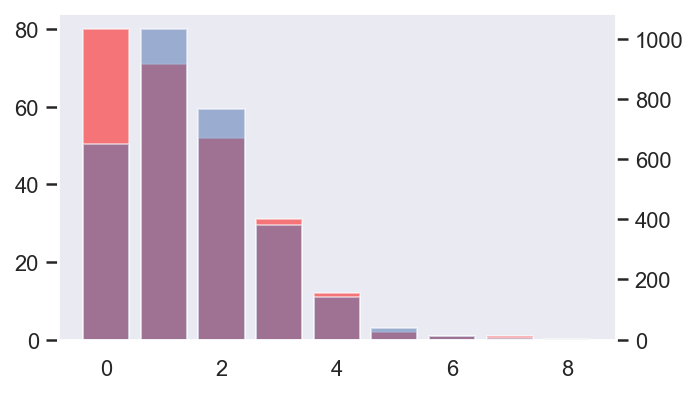

KstestResult(statistic=0.10576137112722478, pvalue=0.010498125918674548, statistic_location=0, statistic_sign=1)
chr11


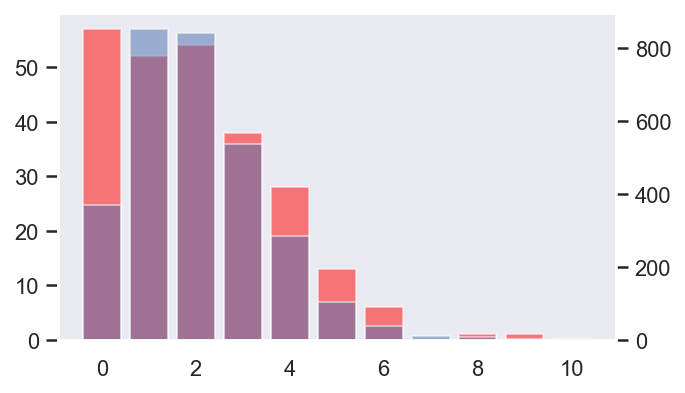

KstestResult(statistic=0.10637837837837838, pvalue=0.009876452006477998, statistic_location=0, statistic_sign=1)
chr12


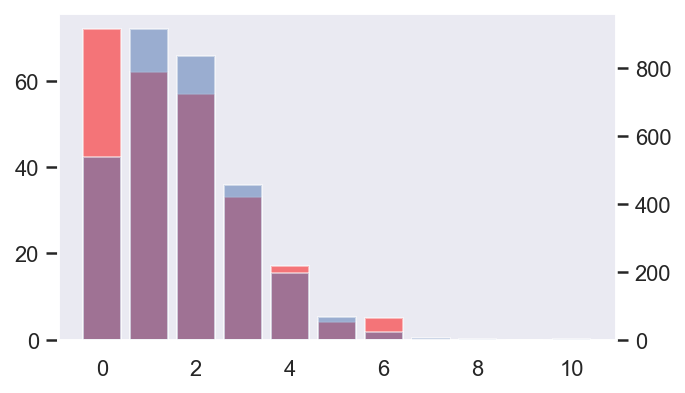

KstestResult(statistic=0.11100593276203033, pvalue=0.0061733822429057145, statistic_location=0, statistic_sign=1)


In [18]:
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import poisson
import scipy.stats as st

def poisson(lambda_, k):
    k = int(k)
    result = (lambda_**k) * (math.exp(-lambda_))  / math.factorial(k)
    return result
sns.set()

for each_chr in tmp.chr.unique():
    print(each_chr)
    chr_recombination_info2 = recombination_info2[recombination_info2.chromosome == each_chr]
    chr_recombination_info = recombination_info[recombination_info.chromosome == each_chr]
    frequency = [(chr_recombination_info2["count"] == i).sum() for i in range(chr_recombination_info2["count"].max()+1)]
    
    fig = plt.figure(figsize=(5,3))

    ax1 = fig.subplots()
    ax2 = ax1.twinx()

    ax1.grid(False)
    ax2.grid(False)

    ax1.bar(x=range(chr_recombination_info2["count"].max()+1), height=frequency, color="red", alpha=0.5)
    
    ax2.bar(x=range(chr_recombination_info["count"].max()+1),
            height=[(chr_recombination_info["count"] == i).sum() for i in range(chr_recombination_info["count"].max()+1)],
            alpha=0.5)
    
    plt.show()
    
    from scipy.stats import kstest
    print(kstest(chr_recombination_info2["count"].values, chr_recombination_info["count"].values))